In [1]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from utils import tabulate_neatly
import SPDE
import yaml
import time

# Flags

Runs experiment for those which are set to true (~10min/experiment)

In [2]:
HEAT = True
NAGUMO = True
ALLEN_CAHN = True

DRIFT = True
DIFFUSION = True

GENERATE_PREDICTION_DATA = True
GENERATE_TRAINING_DATA = True
RUN_LASSO = True
RUN_SINDY = True

ALGORITHMS = {"Lasso": RUN_LASSO, "SINDy": RUN_SINDY}
IDENTIFICATION_TASKS = {"Drift": DRIFT, "Diffusion": DIFFUSION}

#### Generate Data

In [3]:
import DataGenerator as dg

experimentKeys = {"Heat": HEAT,
 "Nagumo": NAGUMO,
 "Allen_Cahn": ALLEN_CAHN}

for key, value in experimentKeys.items():
    if value and GENERATE_TRAINING_DATA:
        dg.generateData(key)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Sample number:  0
Sample number:  100
Sample number:  200
Sample number:  300
Sample number:  400
Sample number:  500
Sample number:  600
Sample number:  700
Sample number:  800
Sample number:  900
Sample number:  1000
Sample number:  1100
Sample number:  1200
Sample number:  1300
Sample number:  1400
Sample number:  1500
Sample number:  1600
Sample number:  1700
Sample number:  1800
Sample number:  1900
uStorage shape: (64, 501, 2000)
xdt shape: (64, 500)
xdiff shape: (64, 500)
Sample number:  0
Sample number:  100
Sample number:  200
Sample number:  300
Sample number:  400
Sample number:  500
Sample number:  600
Sample number:  700
Sample number:  800
Sample number:  900
Sample number:  1000
Sample number:  1100
Sample number:  1200
Sample number:  1300
Sample number:  1400
Sample number:  1500
Sample number:  1600
Sample number:  1700
Sample number:  1800
Sample number: 

#### Mean of Dictionaries

In [4]:


with open("parameters.yaml") as f:
    yamlParameters = yaml.safe_load(f)

space = yamlParameters["common"]["x_end"] - yamlParameters["common"]["x_start"]
timeRange = yamlParameters["common"]["t_end"] - yamlParameters["common"]["t_start"]
timeSteps = yamlParameters["common"]["timesteps"]
spacePoints = yamlParameters["common"]["J"]
isPeriodic = yamlParameters["common"]["periodic"]

problemDictionaries = {}
problemDescriptions = {}

for key, value in experimentKeys.items():
    if value:   
        U = np.load(f'data/{key}_dx_{spacePoints}m_{timeSteps}t.npy')
        dx = space/(U.shape[0])
        dt = timeRange/(U.shape[1]-1)
        Dictt = []
        for i in range(U.shape[2]):
            if i%100==0:
                print(i)
            U_t,Di,description = SPDE.build_linear_system(U[:,:-1,i], dt, dx, D = 5, P = 6 ,periodic=isPeriodic)
            Dictt.append(Di)
        Dictt = np.mean(np.array(Dictt), axis=0)
        problemDictionaries[key] = Dictt
        problemDescriptions[key] = description

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900


# Lasso and SINDy

In [30]:
# the following will be bad swe

Xi_drift_true = {
       "Heat": [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., yamlParameters["heat"]["correct"]["epsilon"], 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.],
       "Nagumo": [0., yamlParameters["nagumo"]["correct"]["u_coeff"], yamlParameters["nagumo"]["correct"]["u2_coeff"], yamlParameters["nagumo"]["correct"]["u3_coeff"]] + [0.]*10 + [yamlParameters["nagumo"]["correct"]["epsilon"]] + [0.]*27, # i do NOT have faith in this
        "Allen_Cahn": [0., yamlParameters["allen_cahn"]["correct"]["u_coeff"], 0., yamlParameters["allen_cahn"]["correct"]["u3_coeff"], 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., yamlParameters["allen_cahn"]["correct"]["epsilon"], 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0.]
}

Xi_diffusion_true = {
       "Heat": [yamlParameters["heat"]["correct"]["sigma"], 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.],
        "Nagumo": [yamlParameters["nagumo"]["correct"]["sigma"], 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.],
        "Allen_Cahn": [yamlParameters["allen_cahn"]["correct"]["sigma"], 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.]
}


In [36]:
results = []

for identificationTask, value in IDENTIFICATION_TASKS.items():
    if value:
        for algorithm, value in ALGORITHMS.items():
            if value:
                for problem, dictionary in problemDictionaries.items():
                    if identificationTask == "Drift":
                        target = np.load(f'data/{problem}_xdt_{spacePoints}m_{timeSteps}t.npy')
                    elif identificationTask == "Diffusion":
                        target = np.load(f'data/{problem}_xdiff_{spacePoints}m_{timeSteps}t.npy')
                    np.random.seed(0)
                    
                    target = target.reshape(1,-1, order='F')
                    start_time = time.time()
                    lam = yamlParameters["common"][f"{algorithm.lower()}_{identificationTask.lower()}_lambda"]
                    if algorithm == "Lasso":
                        Xi_coeffs = SPDE.Lasso(dictionary, target, lam)
                    elif algorithm == "SINDy":
                        Xi_coeffs = SPDE.sindy(lam,dictionary,target)
                    end_time = time.time()

                    targetCoeffs = Xi_drift_true[problem] if identificationTask == "Drift" else Xi_diffusion_true[problem]

                    l2_error = np.linalg.norm(targetCoeffs - Xi_coeffs.reshape(-1))

                    corr_ind = []
                    for i in range(len(targetCoeffs)):
                        if targetCoeffs[i] != 0:
                            corr_ind.append(i)
                    fp = 0
                    for i in range(len(targetCoeffs)):
                        if i in corr_ind:
                            pass
                        else:
                            if Xi_coeffs.reshape(-1)[i] != 0:
                                fp += 1

                    total_negatives = len(targetCoeffs) - len(corr_ind)
                    fpr = (fp / total_negatives) * 100

                    results.append([f"{problem} | {identificationTask}", algorithm, round(l2_error, 4), round(fpr, 2), round(end_time - start_time, 4)])

tabulate_neatly(results, headers=["Problem", "Algorithm", "L2 Error", "FPR (%)", "Time (s)"], title="Identification Results")

Identification Results

Problem,Algorithm,L2 Error,FPR (%),Time (s)
Heat | Drift,Lasso,0.8275,80.49,1.8145
Nagumo | Drift,Lasso,1.0218,57.89,1.7005
Allen_Cahn | Drift,Lasso,0.7639,74.36,1.8439
Heat | Drift,SINDy,0.0135,0,0.0685
Nagumo | Drift,SINDy,0.0516,0,0.0977
Allen_Cahn | Drift,SINDy,0.008,0,0.0851
Heat | Diffusion,Lasso,0.1764,85.37,1.7651
Nagumo | Diffusion,Lasso,0.1827,75.61,1.8274
Allen_Cahn | Diffusion,Lasso,0.2286,92.68,1.743
Heat | Diffusion,SINDy,0.0208,0,0.0905


# Variational Bayes

NOTE: Fixed, using zero-initialisation

In [37]:
results_vb = []
problemDS = {}
results_vb_variances = []

for identificationTask, value in IDENTIFICATION_TASKS.items():
    if value:
        for problem, dictionary in problemDictionaries.items():
            if identificationTask == "Drift":
                target = np.load(f'data/{problem}_xdt_{spacePoints}m_{timeSteps}t.npy')
            elif identificationTask == "Diffusion":
                target = np.load(f'data/{problem}_xdiff_{spacePoints}m_{timeSteps}t.npy')
            y = target.reshape(-1, order='F')
            np.random.seed(10)
            initz0 = np.random.normal(0, 1, size=dictionary.shape[1])
            # initz0 = np.zeros(dictionary.shape[1])
            tol = 0.000001
            verbosity = True

            start_time = time.time()
            DS = SPDE.Variational_Bayes_Code(dictionary, y, initz0, tol, verbosity)
            problemDS.setdefault(problem, {})[identificationTask] = DS
            end_time = time.time()

            # neglecting the small coefficients whose value is less than 0.01
            for i in range((dictionary.shape[1])):
                if abs(DS['wmean'][i]) <= 0.01:
                    DS['zmean'][i] = 0
                    DS['wmean'][i] = 0
                
            targetCoeffs = Xi_drift_true[problem] if identificationTask == "Drift" else Xi_diffusion_true[problem]

            l2_error_vb = np.linalg.norm(targetCoeffs - DS['wmean'])

            corr_ind = []
            for i in range(len(targetCoeffs)):
                if targetCoeffs[i] != 0:
                    corr_ind.append(i)

            fp_vb = 0
            for i in range(len(targetCoeffs)):
                if i in corr_ind:
                    pass
                else:
                    if DS['wmean'][i] != 0:
                        fp_vb += 1

            total_negatives = len(targetCoeffs) - len(corr_ind)
            fpr_vb = (fp_vb / total_negatives) * 100

            results_vb.append([f"{problem} | {identificationTask}", round(l2_error_vb, 4), round(fpr_vb, 2), round(end_time - start_time, 4)])

            # variance table - only for discovered terms (PIP > 0.5)
            variances = np.diag(DS['wCOV'])
            for i in range(len(DS['zmean'])):
                if DS['zmean'][i] > 0.5:
                    label = description[i] if description[i] != '' else '1'
                    results_vb_variances.append([
                        f"{problem} | {identificationTask}",
                        label,
                        round(float(DS['wmean'][i]), 4),
                        round(float(variances[i]), 6)
                    ])
                    

tabulate_neatly(results_vb, headers=["Problem", "L2 Error", "FPR (%)", "Time (s)"], title="Variational Bayes Drift Results")
tabulate_neatly(results_vb_variances, headers=["Problem", "Term", "Mean", "Variance"], title="Variational Bayes Discovered Coefficients")

c:\Users\bluem\OneDrive\Documents\University\Masters\Modules\Project\Programming\Stochastic-PDE-Discovery\SPDE.py:427: RuntimeWarning: divide by zero encountered in log
  + np.nansum((1 - zm) * (np.log(1 - p0) - np.log(1 - zm)))
c:\Users\bluem\OneDrive\Documents\University\Masters\Modules\Project\Programming\Stochastic-PDE-Discovery\SPDE.py:427: RuntimeWarning: invalid value encountered in multiply
  + np.nansum((1 - zm) * (np.log(1 - p0) - np.log(1 - zm)))
c:\Users\bluem\OneDrive\Documents\University\Masters\Modules\Project\Programming\Stochastic-PDE-Discovery\SPDE.py:457: RuntimeWarning: overflow encountered in exp
  expitC = 1.0 / (1 + np.exp(-C))


Iteration = 0  log(Likelihood) = -27856.298421190993


c:\Users\bluem\OneDrive\Documents\University\Masters\Modules\Project\Programming\Stochastic-PDE-Discovery\SPDE.py:426: RuntimeWarning: divide by zero encountered in log
  + np.nansum(zm * (np.log(p0) - np.log(zm)))
c:\Users\bluem\OneDrive\Documents\University\Masters\Modules\Project\Programming\Stochastic-PDE-Discovery\SPDE.py:426: RuntimeWarning: invalid value encountered in multiply
  + np.nansum(zm * (np.log(p0) - np.log(zm)))


Iteration = 1  log(Likelihood) = -22882.977654235354
Iteration = 2  log(Likelihood) = -22661.283001207667
Iteration = 3  log(Likelihood) = -22646.666668802667
Iteration = 4  log(Likelihood) = -22646.666668764923
Iteration = 0  log(Likelihood) = -25924.533484321946
Iteration = 1  log(Likelihood) = -23363.451788390663
Iteration = 2  log(Likelihood) = -23336.786189958693
Iteration = 3  log(Likelihood) = -23336.786189416678


c:\Users\bluem\OneDrive\Documents\University\Masters\Modules\Project\Programming\Stochastic-PDE-Discovery\SPDE.py:425: RuntimeWarning: invalid value encountered in log
  + 0.5 * np.log(la.det(Sigma))


Iteration = 0  log(Likelihood) = nan
Iteration = 1  log(Likelihood) = -23707.635398261744
Iteration = 2  log(Likelihood) = -23531.782622039696
Iteration = 3  log(Likelihood) = -23519.161812187318
Iteration = 4  log(Likelihood) = -23519.161811020687
Iteration = 5  log(Likelihood) = -23519.161811020705
OOPS!  log(like) decreasing!!
Iteration = 6  log(Likelihood) = -23519.16181102068
Iteration = 0  log(Likelihood) = 64813.80226665323
Iteration = 1  log(Likelihood) = 65280.69900422987
Iteration = 2  log(Likelihood) = 65346.55500292423
Iteration = 3  log(Likelihood) = 65327.60948749205
OOPS!  log(like) decreasing!!
Iteration = 4  log(Likelihood) = 65327.609515732824
Iteration = 5  log(Likelihood) = 65327.609515728116
OOPS!  log(like) decreasing!!
Iteration = 6  log(Likelihood) = 65327.60951572599
OOPS!  log(like) decreasing!!
Iteration = 7  log(Likelihood) = 65327.60951572608
Iteration = 0  log(Likelihood) = 65328.203405609
Iteration = 1  log(Likelihood) = 65643.37413362347
Iteration = 2  l

Variational Bayes Drift Results

Problem,L2 Error,FPR (%),Time (s)
Heat | Drift,0.0135,0,2.1038
Nagumo | Drift,1.4169,13.16,1.6521
Allen_Cahn | Drift,1.8862,10.26,2.7341
Heat | Diffusion,0.0208,0,3.2893
Nagumo | Diffusion,0.0214,0,1.5326
Allen_Cahn | Diffusion,0.021,0,2.2273


Variational Bayes Discovered Coefficients

Problem,Term,Mean,Variance
Heat | Drift,u_{xx},0.9865,2.8e-05
Nagumo | Drift,1,0.0755,3.1e-05
Nagumo | Drift,u^4,0.4756,0.00039
Nagumo | Drift,u_{xx},0.7774,0.001754
Nagumo | Drift,u^4u_{xx},0.4701,0.004197
Nagumo | Drift,u_{xxxx},-0.0363,2.2e-05
Nagumo | Drift,u^2u_{xxxx},0.0621,0.000221
Allen_Cahn | Drift,1,0.0794,0.000188
Allen_Cahn | Drift,u^3,0.5263,0.0046
Allen_Cahn | Drift,u_{xx},0.6091,0.00025


### Plots

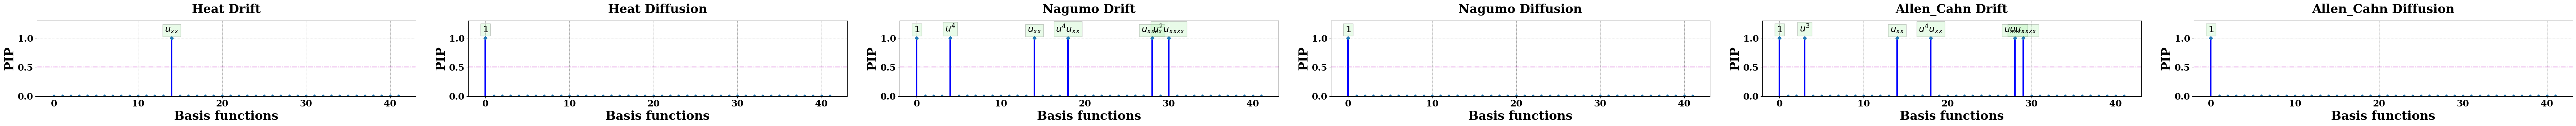

In [38]:
plt.rcParams["font.family"] = "serif"
plt.rcParams['font.size'] = 24

fig, axes = plt.subplots(1, len(problemDictionaries) * (2 if (DRIFT and DIFFUSION) else 1), figsize=(12 * len(problemDictionaries) * (2 if (DRIFT and DIFFUSION) else 1), 4))
axes = np.atleast_1d(axes)  # ensures axes is always an array even with 1 subplot

ax_idx = 0
for problem, experimentSet in problemDS.items():
    for identificationTask, DS in experimentSet.items():
        ax = axes[ax_idx]
        ax_idx += 1
        xr = np.array(range(len(DS['zmean'])))

        ax.vlines(xr, 0, DS['zmean'], colors='blue', linewidth=3.0)
        ax.plot(xr, DS['zmean'], 'C0D', markersize=5)
        ax.axhline(y=0.5, color='m', linestyle='-.')

        # annotate discovered terms with PIP > 0.5
        description = problemDescriptions[problem]
        for i, pip in enumerate(DS['zmean']):
            if pip > 0.5:
                label = f"${description[i]}$" if description[i] != '' else '$1$'
                ax.text(i, 1.1, label, bbox=dict(facecolor='lightgreen', alpha=0.2), fontsize=18, ha='center')

        ax.set_xlabel('Basis functions', fontweight='bold', fontsize=24)
        ax.set_ylabel('PIP', fontweight='bold', fontsize=24)
        ax.set_title(f'{problem} {identificationTask}', fontweight='bold', fontsize=24, pad=15)
        ax.grid(color='gray', linestyle='--', linewidth=0.5)
        ax.set_ylim(0, 1.3)
        ax.tick_params(axis='both', labelsize=18)
        for tick in ax.get_xticklabels() + ax.get_yticklabels():
            tick.set_fontweight('bold')

plt.tight_layout()
plt.show()

### Write Coeffs out to yaml

In [39]:
for problem, experimentSet in problemDS.items():
    for identificationTask, DS in experimentSet.items():
        disc = yamlParameters[problem.lower()]["discovered"]
        variances = np.diag(DS['wCOV'])
        
        # map description labels to discovered values and variances
        for i in range(len(DS['zmean'])):
            if DS['zmean'][i] > 0.5:
                description = problemDescriptions[problem]
                label = description[i] if description[i] != '' else '1'
                mean_val = round(float(DS['wmean'][i]), 6)
                var_val  = round(float(variances[i]), 8)
                
                #clean this up it looks terrible - maybe use a dictionary to map labels to yaml keys?
                #probably retrieve how this is done from SPDE.py and use the same mapping here to ensure consistency
                label_to_yaml = {
                    'u_{xx}': ('epsilon', 'epsilon_variance'),
                    '1': ('sigma_squared', 'sigma_squared_variance'),
                    'u': ('u_coeff', 'u_coeff_variance'),
                    'u^2': ('u2_coeff', 'u2_coeff_variance'),
                    'u^3': ('u3_coeff', 'u3_coeff_variance')
                }
                
                if label in label_to_yaml:
                    yaml_key, yaml_variance_key = label_to_yaml[label]
                    disc[yaml_key] = mean_val
                    disc[yaml_variance_key] = var_val

with open("parameters.yaml", "w") as f:
    yaml.dump(yamlParameters, f, default_flow_style=False, sort_keys=False)

# Prediction

Generate data per discovered coefficients

correct sample: 0
correct sample: 50
correct sample: 100
correct sample: 150
correct shape: (64, 501, 200)
pred sample: 0
pred sample: 50
pred sample: 100
pred sample: 150
pred shape: (64, 501, 200)


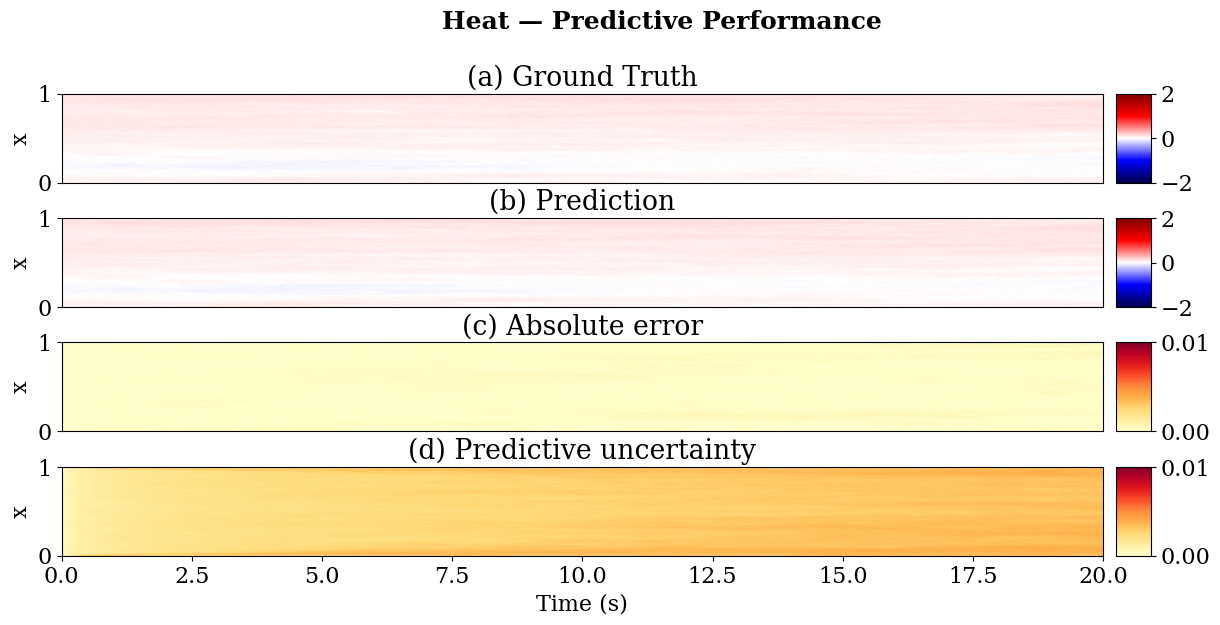

0.003944962046571027
correct sample: 0
correct sample: 50
correct sample: 100
correct sample: 150
correct shape: (64, 501, 200)
pred sample: 0
pred sample: 50
pred sample: 100
pred sample: 150
pred shape: (64, 501, 200)


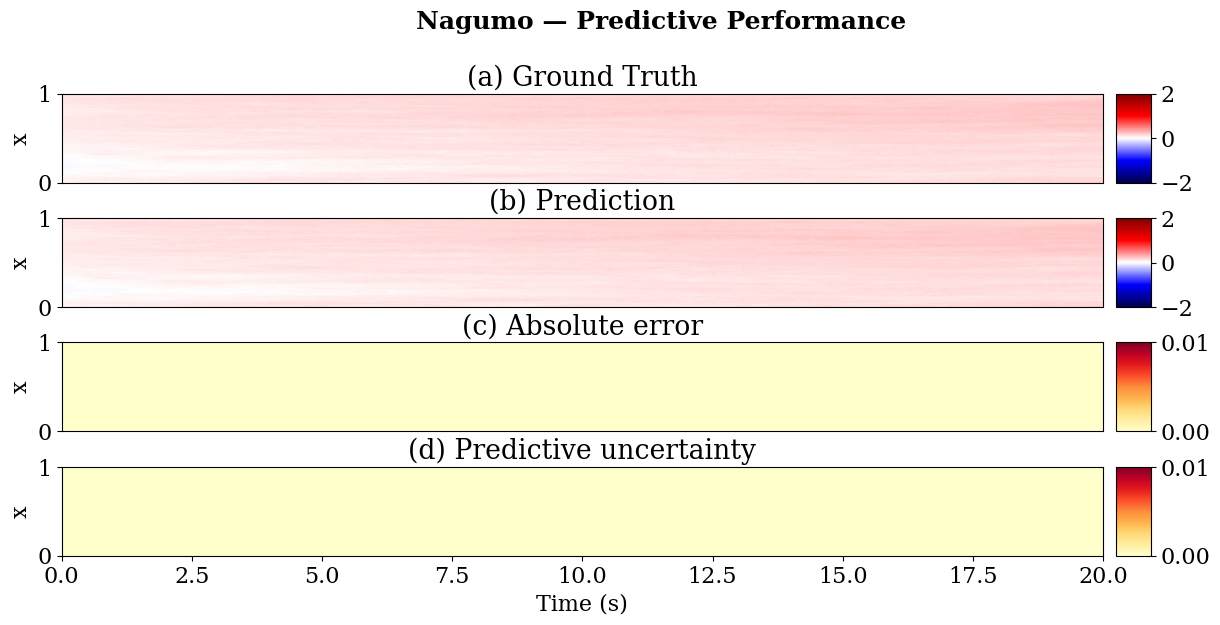

0.0
correct sample: 0
correct sample: 50
correct sample: 100
correct sample: 150
correct shape: (64, 501, 200)
pred sample: 0
pred sample: 50
pred sample: 100
pred sample: 150
pred shape: (64, 501, 200)


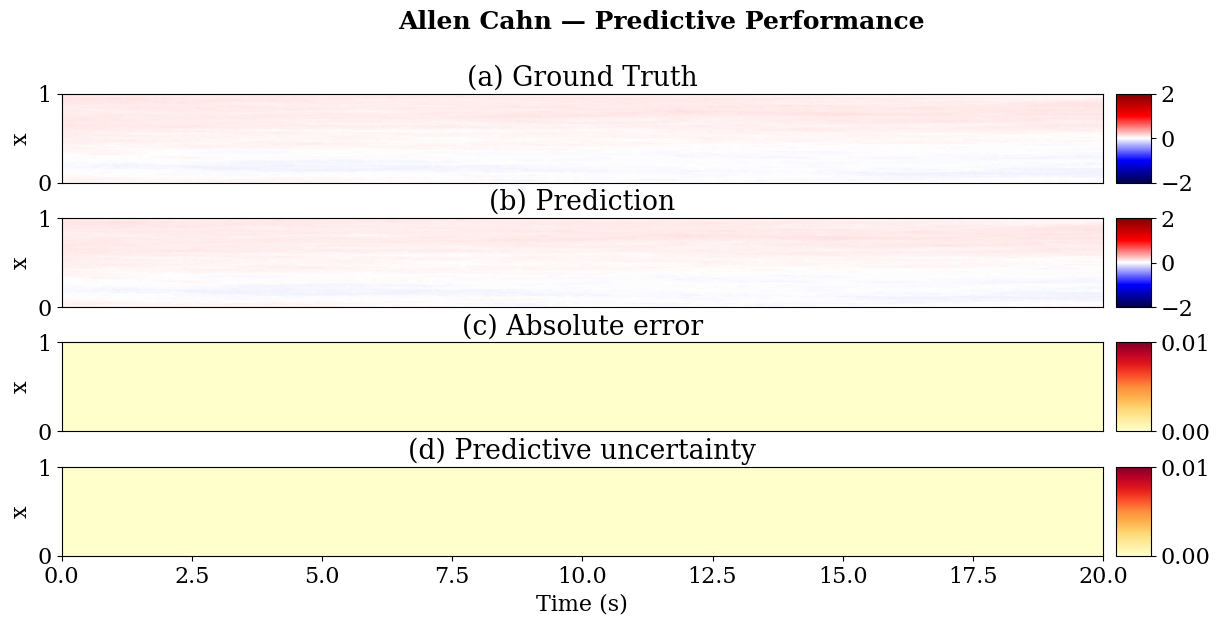

0.0


In [41]:
import PredictionDataGenerator

with open("parameters.yaml") as f:
    yamlParameters = yaml.safe_load(f)

for key, value in experimentKeys.items():
    if value:
        if GENERATE_PREDICTION_DATA:
            PredictionDataGenerator.generatePrediction(key)
        
        U3 = np.load(f'data/{key}_prediction_correct.npy')
        U4 = np.load(f'data/{key}_prediction_pred.npy')
        plt.rcParams['font.size'] = 16

        fig = plt.figure(figsize=(16,6))
        fig.subplots_adjust(wspace=1, hspace=0.4)
        
        solution_cmap = 'seismic'      # diverging for solution fields
        error_cmap = 'YlOrRd'          # sequential for error/uncertainty

        plt.subplot(4,1,1)
        uu = np.mean(U3, axis=2)
        plt.imshow(uu, cmap=solution_cmap, aspect='auto', origin='lower', extent=[0, 20, 0, 1], vmin=-2, vmax=2)
        plt.ylabel('x')
        plt.title('(a) Ground Truth')
        plt.xticks([], [])
        plt.colorbar(aspect=2.5, pad=0.01)

        plt.subplot(4,1,2)
        uu1 = np.mean(U4, axis=2)
        plt.imshow(uu1, cmap=solution_cmap, aspect='auto', origin='lower', extent=[0, 20, 0, 1], vmin=-2, vmax=2)
        plt.ylabel('x')
        plt.title('(b) Prediction')
        plt.xticks([], [])
        plt.colorbar(aspect=2.5, pad=0.01)

        plt.subplot(4,1,3)
        plt.imshow(np.abs(uu - uu1), cmap=error_cmap, aspect='auto', origin='lower', extent=[0, 20, 0, 1], vmin=0, vmax=0.01)
        plt.ylabel('x')
        plt.title('(c) Absolute error')
        plt.xticks([], [])
        plt.colorbar(aspect=2.5, pad=0.01)

        plt.subplot(4,1,4)
        plt.imshow(np.std(U3 - U4, axis=2), cmap=error_cmap, aspect='auto', origin='lower', extent=[0, 20, 0, 1], vmin=0, vmax=0.01)
        plt.xlabel('Time (s)')
        plt.ylabel('x')
        plt.title('(d) Predictive uncertainty')
        plt.colorbar(aspect=2.5, pad=0.01)

        fig.suptitle(f'{key.replace("_", " ").title()} — Predictive Performance', fontweight='bold', fontsize=18, y=1.02)

        plt.show()
        print(np.max(np.std(U3 - U4, axis=2)))
        fig.savefig(f'data/{key}_prediction.pdf', format='pdf', dpi=300, bbox_inches='tight')